# **EXOPLANET HABITABILITY CLASSIFICATION PROJECT**

### RIDIMA

This notebook is a ML project, classifying exoplanets on their habitability from various mission data. 

In [ ]:
#Import all the essentials libraries

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import dabl as db
import time



from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV,StratifiedKFold, RandomizedSearchCV
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, classification_report, confusion_matrix 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder



#Machine Learning Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostRegressor as Ada
from sklearn.multiclass import OneVsRestClassifier as Ovr
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

In [2]:
#Open the data
df = pd.read_csv("phl_exoplanet_catalog_2019.csv")
df.head()

,P_NAME,P_STATUS,P_MASS,P_MASS_ERROR_MIN,P_MASS_ERROR_MAX,P_RADIUS,P_RADIUS_ERROR_MIN,P_RADIUS_ERROR_MAX,P_YEAR,P_UPDATED,...,P_HABZONE_CON,P_TYPE_TEMP,P_HABITABLE,P_ESI,S_CONSTELLATION,S_CONSTELLATION_ABR,S_CONSTELLATION_ENG,P_RADIUS_EST,P_MASS_EST,P_SEMI_MAJOR_AXIS_EST
0,11 Com b,3.0,6165.86330,-476.74200,476.74200,NaN,NaN,NaN,2007,2014-05-14,...,0,Hot,0,0.083813,Coma Berenices,Com,Berenice's Hair,12.082709,6165.86330,1.29
1,11 UMi b,3.0,4684.78480,-794.57001,794.57001,NaN,NaN,NaN,2009,2018-09-06,...,0,Hot,0,0.082414,Ursa Minor,UMi,Little Bear,12.229641,4684.78480,1.53
2,14 And b,3.0,1525.57440,NaN,NaN,NaN,NaN,NaN,2008,2014-05-14,...,0,Hot,0,0.081917,Andromeda,And,Andromeda,12.848516,1525.57440,0.83
3,14 Her b,3.0,1481.07850,-47.67420,47.67420,NaN,NaN,NaN,2002,2018-09-06,...,0,Cold,0,0.145241,Hercules,Her,Hercules,12.865261,1481.07850,2.93
4,16 Cyg B b,3.0,565.73385,-25.42624,25.42624,NaN,NaN,NaN,1996,2018-09-06,...,1,Warm,0,0.368627,Cygnus,Cyg,Swan,13.421749,565.73385,1.66


In [3]:
with open("column_names.txt", "w") as f:
    for i, col in enumerate(df.columns, start=1):
        f.write(f"{i}. {col}\n")
df.columns

Index(['P_NAME', 'P_STATUS', 'P_MASS', 'P_MASS_ERROR_MIN', 'P_MASS_ERROR_MAX',
       'P_RADIUS', 'P_RADIUS_ERROR_MIN', 'P_RADIUS_ERROR_MAX', 'P_YEAR',
       'P_UPDATED',
       ...
       'P_HABZONE_CON', 'P_TYPE_TEMP', 'P_HABITABLE', 'P_ESI',
       'S_CONSTELLATION', 'S_CONSTELLATION_ABR', 'S_CONSTELLATION_ENG',
       'P_RADIUS_EST', 'P_MASS_EST', 'P_SEMI_MAJOR_AXIS_EST'],
      dtype='object', length=112)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4048 entries, 0 to 4047
Columns: 112 entries, P_NAME to P_SEMI_MAJOR_AXIS_EST
dtypes: float64(94), int64(4), object(14)
memory usage: 3.5+ MB


In [5]:
shape = df.shape
print(f'Rows: {shape[0]}')
print(f'Columns: {shape[1]}')

Rows: 4048
Columns: 112


Our target column is P_HABITABLE< which is a multiclass column.

Let's visualize the imbalance

# **EDA**

Target looks like classification
Showing only top 10 of 84 continuous features
Linear Discriminant Analysis training set score: 0.865


[<Axes: title={'center': 'Target distribution'}, xlabel='count', ylabel='P_HABITABLE'>,
 [<Figure size 2000x600 with 10 Axes>,
  array([[<Axes: title={'center': '0.776'}, xlabel='P_ESI', ylabel='P_TEMP_EQUIL'>,
          <Axes: title={'center': '0.770'}, xlabel='P_ESI', ylabel='P_TEMP_EQUIL_MIN'>,
          <Axes: title={'center': '0.749'}, xlabel='P_ESI', ylabel='P_TEMP_EQUIL_MAX'>,
          <Axes: title={'center': '0.727'}, xlabel='P_ESI', ylabel='S_TEMPERATURE'>]],
        dtype=object),
  <Figure size 1600x400 with 4 Axes>,
  <Figure size 400x400 with 1 Axes>],
 array([[<Axes: title={'center': 'P_TYPE_TEMP'}>,
         <Axes: title={'center': 'P_TYPE'}>,
         <Axes: title={'center': 'S_TYPE_TEMP'}>,
         <Axes: title={'center': 'P_DETECTION'}>]], dtype=object)]

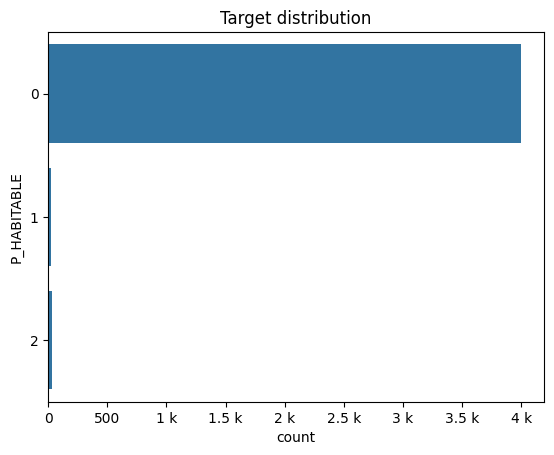

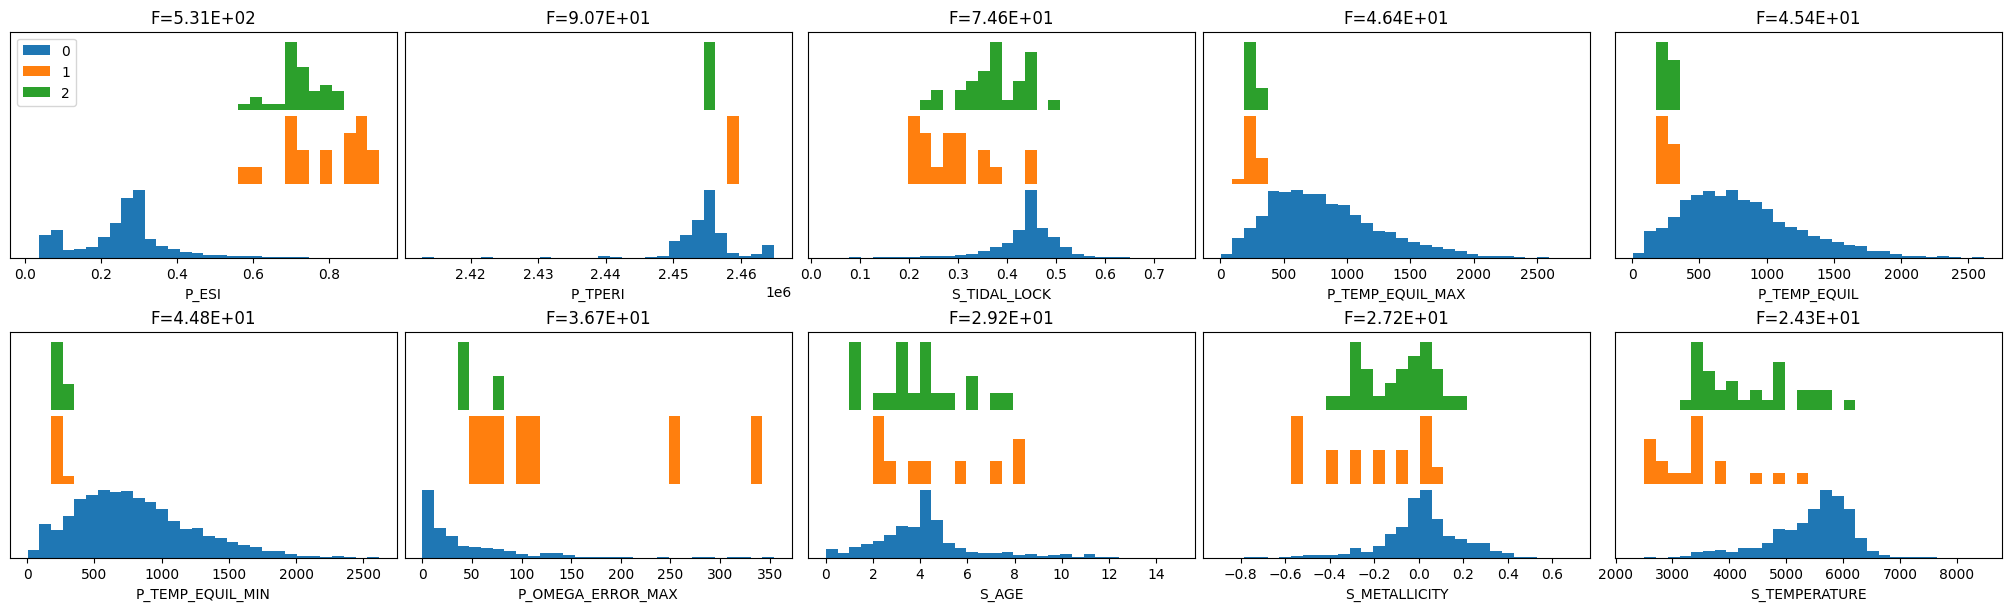

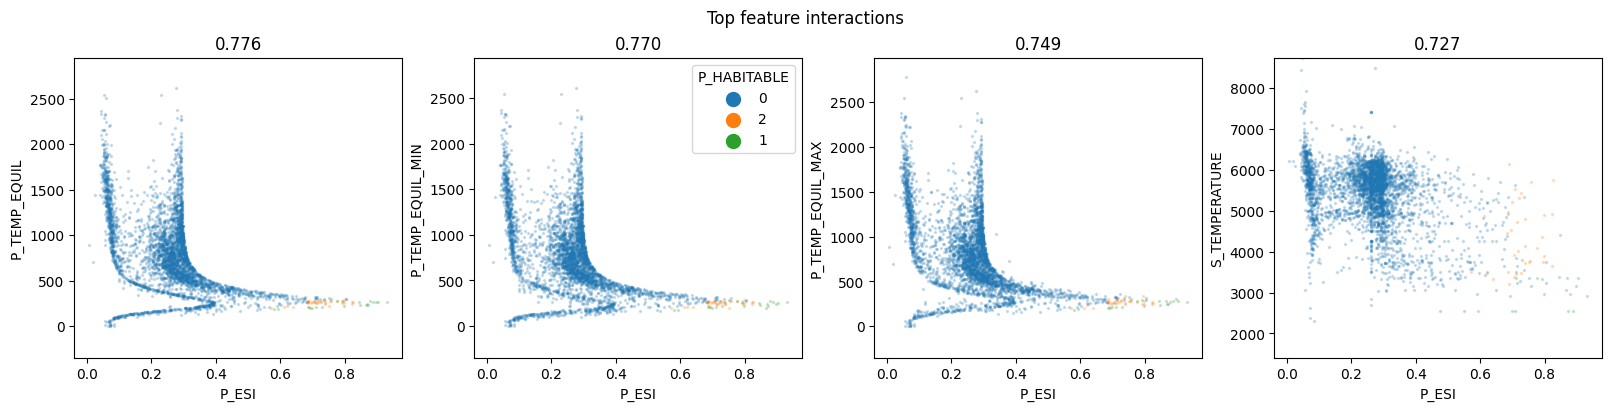

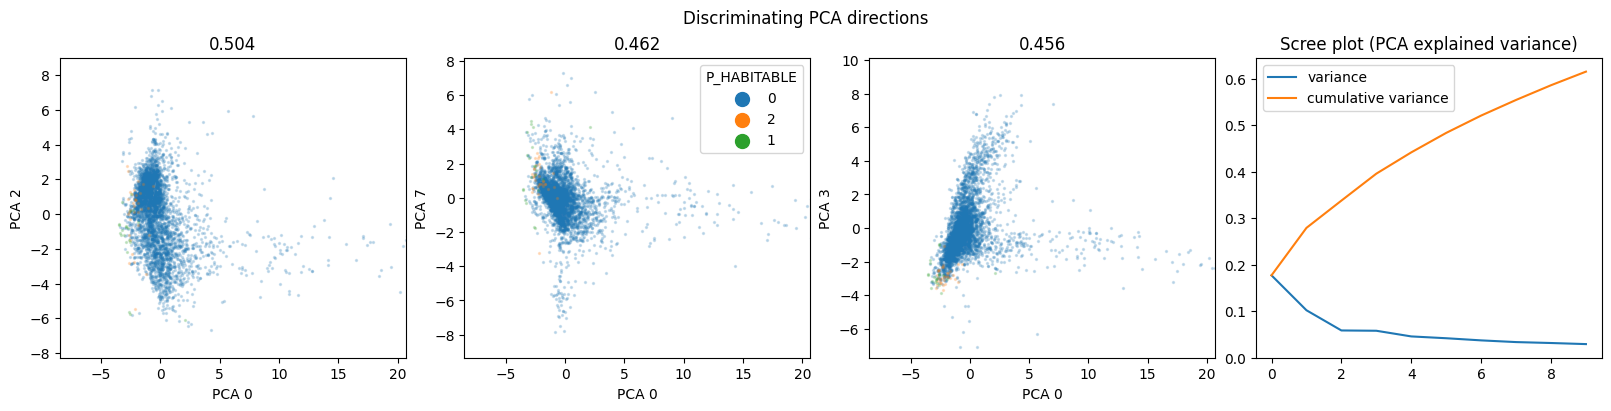

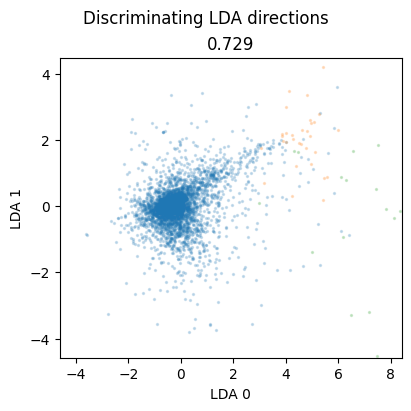

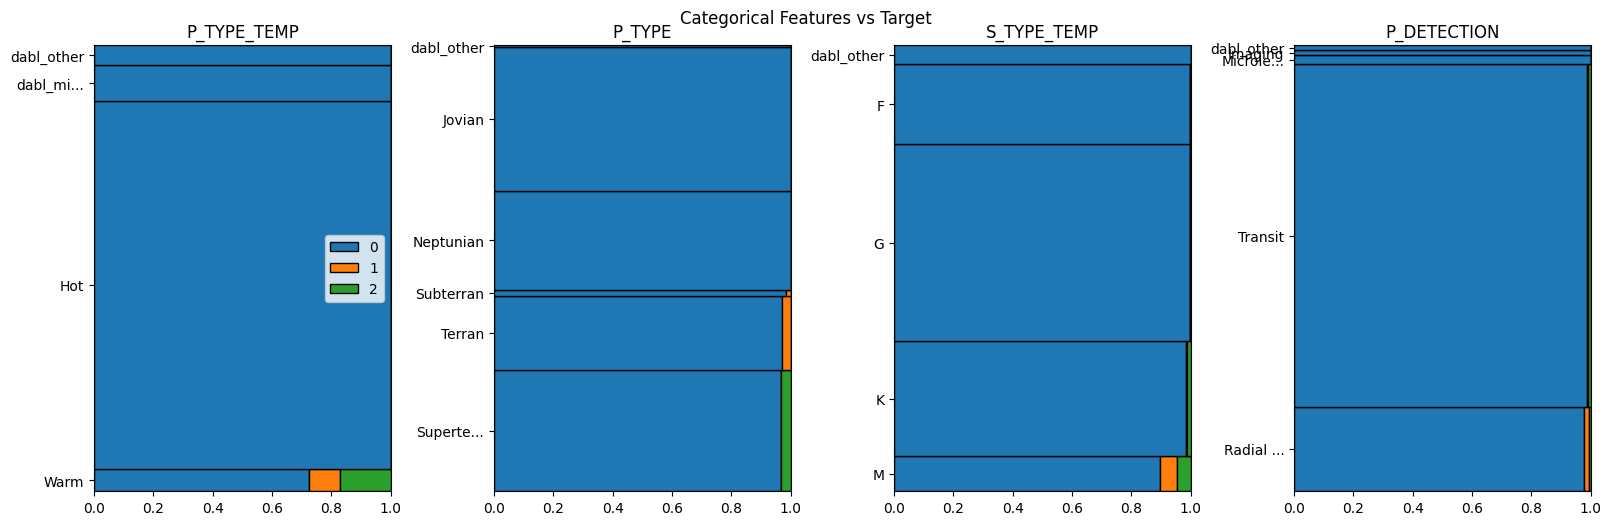

In [6]:
import warnings
warnings.filterwarnings('ignore')
db.plot(df, target_col='P_HABITABLE')

In [7]:
count = df['P_HABITABLE'].value_counts().sort_index()
total = count.sum()
percentage  = (count/total)*100
print(f'Percentage of class Imbalance:  ${percentage}')

Percentage of class Imbalance:  $P_HABITABLE
0    98.641304
1     0.518775
2     0.839921
Name: count, dtype: float64


Clearly the dataset is imbalanced as it have 98% inhabitable planets, 0.51% potentially habitable planets and 0.83% potentially habitable. 

# **Data Analysis Through Visualization**

We can visualize, what techniques were used to detect exoplanets

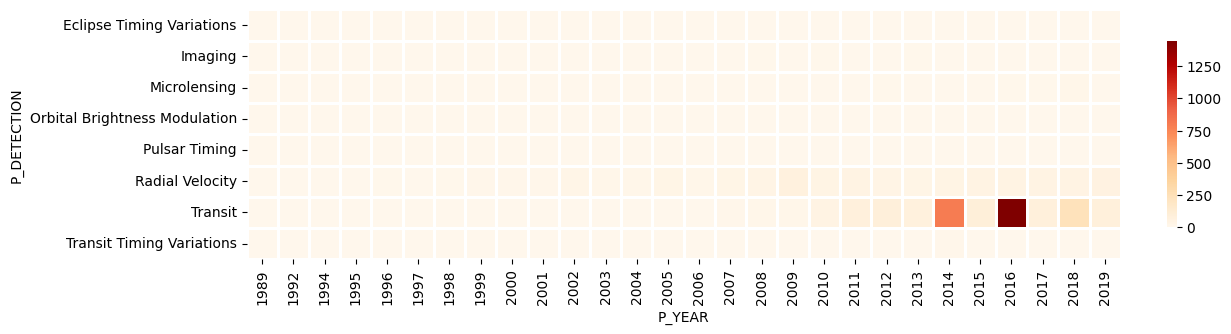

In [8]:
planet_detect = (df.groupby("P_DETECTION").filter(lambda x: len(x)>5)).groupby(['P_DETECTION', 'P_YEAR']).size().unstack(fill_value=0)

plt.figure(figsize=(12,12))
g = sns.heatmap(
    planet_detect, 
    square=True, 
    cbar_kws={'fraction' : 0.01}, 
    cmap='OrRd',
    linewidth=1
)
plt.savefig('Detection-method-by-year.png')

We can observe that Transit detection technique had been used extensively for discovering exoplanets

Now we can plot habitability of these planets detected by this detection method.

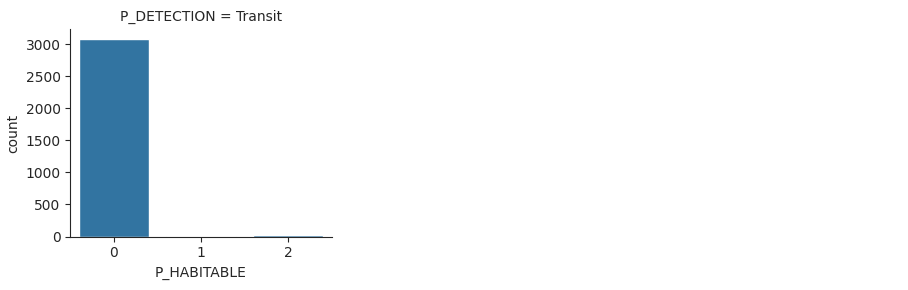

In [9]:
with sns.axes_style(style='ticks'):
    g = sns.catplot(x = "P_HABITABLE", 
                    col="P_DETECTION", 
                    col_wrap=3, 
                    data=df[
                        df['P_DETECTION'].isin(['Transit'])],
                    kind="count",
                    height=3.0, 
                    aspect=1.0)

plt.savefig("Class-Distro-by-method-detection.png")

Transit method discovered inhabitable planets more

**Planets discovered under a star in an year**

Now we can analyze which planet (under which star) was discovered in which year.

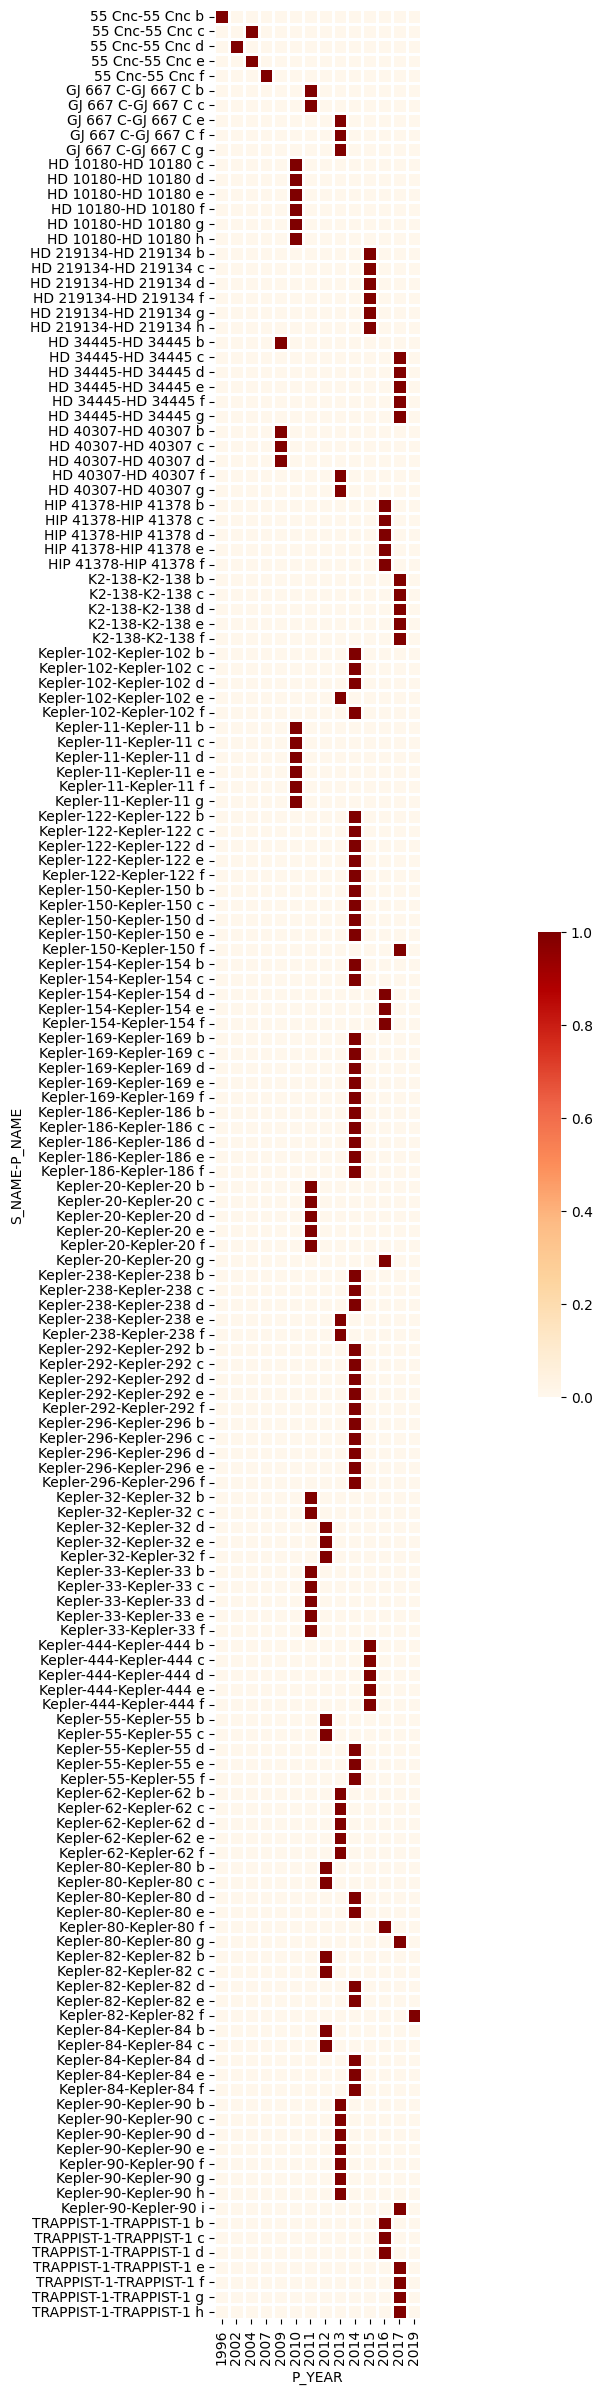

In [10]:
planet_under_star = (df.groupby("S_NAME").filter(lambda x: len(x)>4).groupby(['S_NAME', 'P_NAME', 'P_YEAR']).size().unstack(fill_value = 0))

plt.figure(figsize=(30,30))

g = sns.heatmap(planet_under_star,square=True, cbar_kws={'fraction':0.01},cmap='OrRd', linewidths=1)


The Kepler systems show the highest concentration of discoveries, mainly between 2010 and 2016. Systems such as Kepler-11 contain several planets discovered within a similar period, while Kepler-102 has planets b, c, d, and f recorded in 2014, creating a tight vertical cluster.

The TRAPPIST systems were mostly discovered later, around 2016–2019. Overall, the figure shows a shift from individual planets discovered over different years in older systems, such as 55 Cancri, to multiple planets being detected together in compact systems during the Kepler era. This is reflected by the dense vertical clusters toward the right side of the heatmap.


-----------------------------------------------------------------------------

**Influence of planet,star type on habitability**

Now we can explore how planet type, star spectral type and planet thermal type influences habitability of exoplanet.

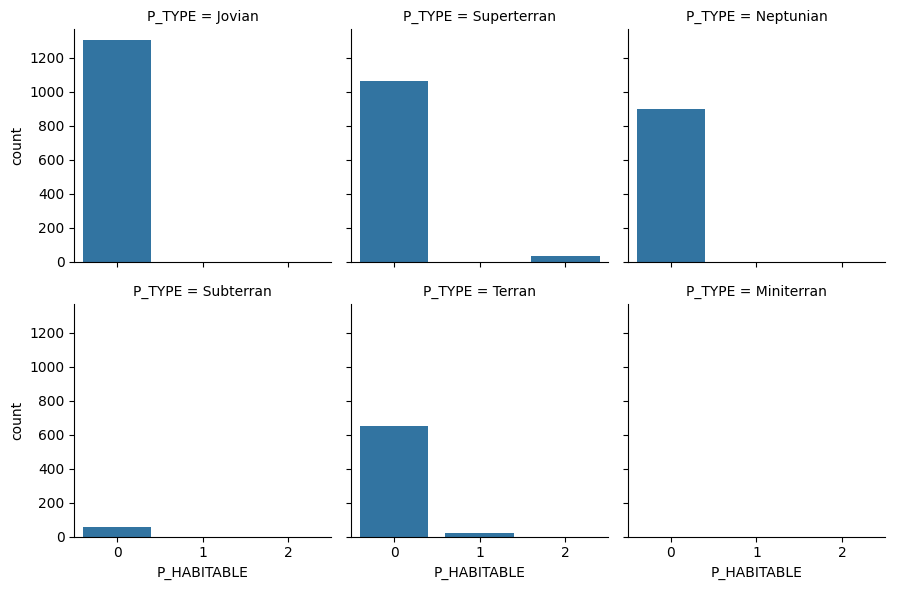

In [11]:
sns.axes_style(style='ticks')
g = sns.catplot(x = "P_HABITABLE", col = "P_TYPE", col_wrap=3, data = df, kind = 'count', height= 3,aspect=1.0)
plt.savefig("P_type-by-class-distro.png")

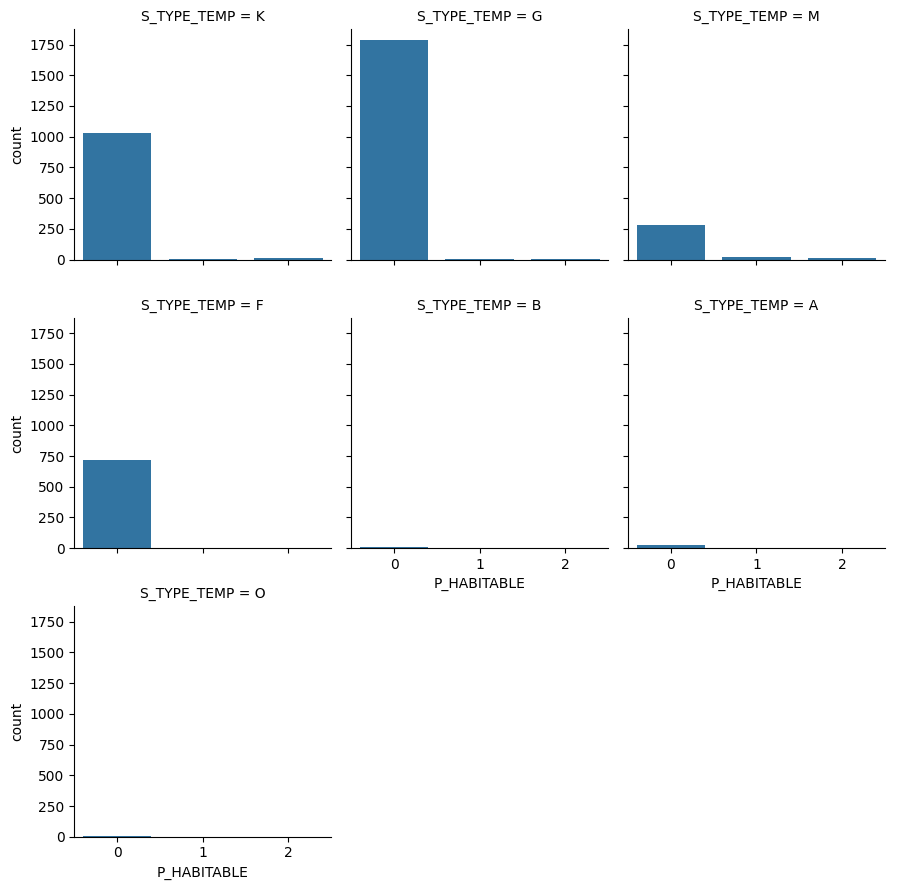

In [12]:
sns.axes_style(style='ticks')
g = sns.catplot(x = "P_HABITABLE", col = "S_TYPE_TEMP", col_wrap=3, data = df, kind = 'count', height= 3,aspect=1.0)
plt.savefig("S_type_temp-by-class-distro.png")

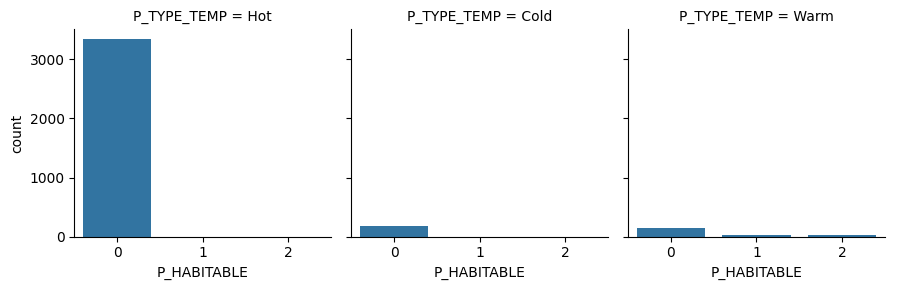

In [13]:
sns.axes_style(style='ticks')
g = sns.catplot(x = "P_HABITABLE", col = "P_TYPE_TEMP", col_wrap=3, data = df, kind = 'count', height= 3,aspect=1.0)
plt.savefig('ptype-by-target-distro.png')

The results indicate that Superterran planets are more frequently associated with inhabitability, whereas Terran planets show comparatively higher number of positive habitable planets. In terms of stellar spectral type, S-type stars have a high occurrence of inhabitable planets. Additionally, hot planets show the highest numbers of inhabitability, suggesting a strong association between warm thermal conditions and planetary habitability.

-------------------------------------------------------------------------------

**Habitability over years**

Now we can plot how many habitable exoplanets were discovered over years

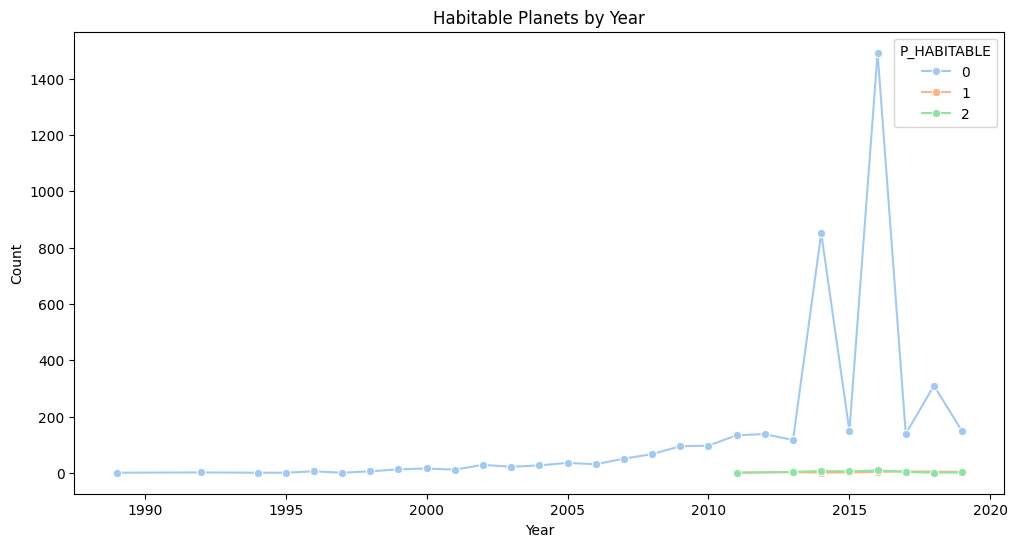

In [11]:
count_data = (
    df
    .groupby(["P_YEAR", "P_HABITABLE"])
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=count_data,
    x="P_YEAR",
    y="count",
    hue="P_HABITABLE",
    marker="o",
    palette="pastel"
)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Habitable Planets by Year")
plt.savefig("Habitable-Planets-by-Year.png")
plt.show()


From the above lineplot, we can infer that in around 2014-2015 we see maximum number of discovery of  inhabitable exoplanet.

-------------------------------------------------------------------------------

**Planet thermal type influencing ESI**

Now, we can plot how planet thermal type is influencing the earth similarity index, and how ESI affect the possibility of and exoplanet being habitual.

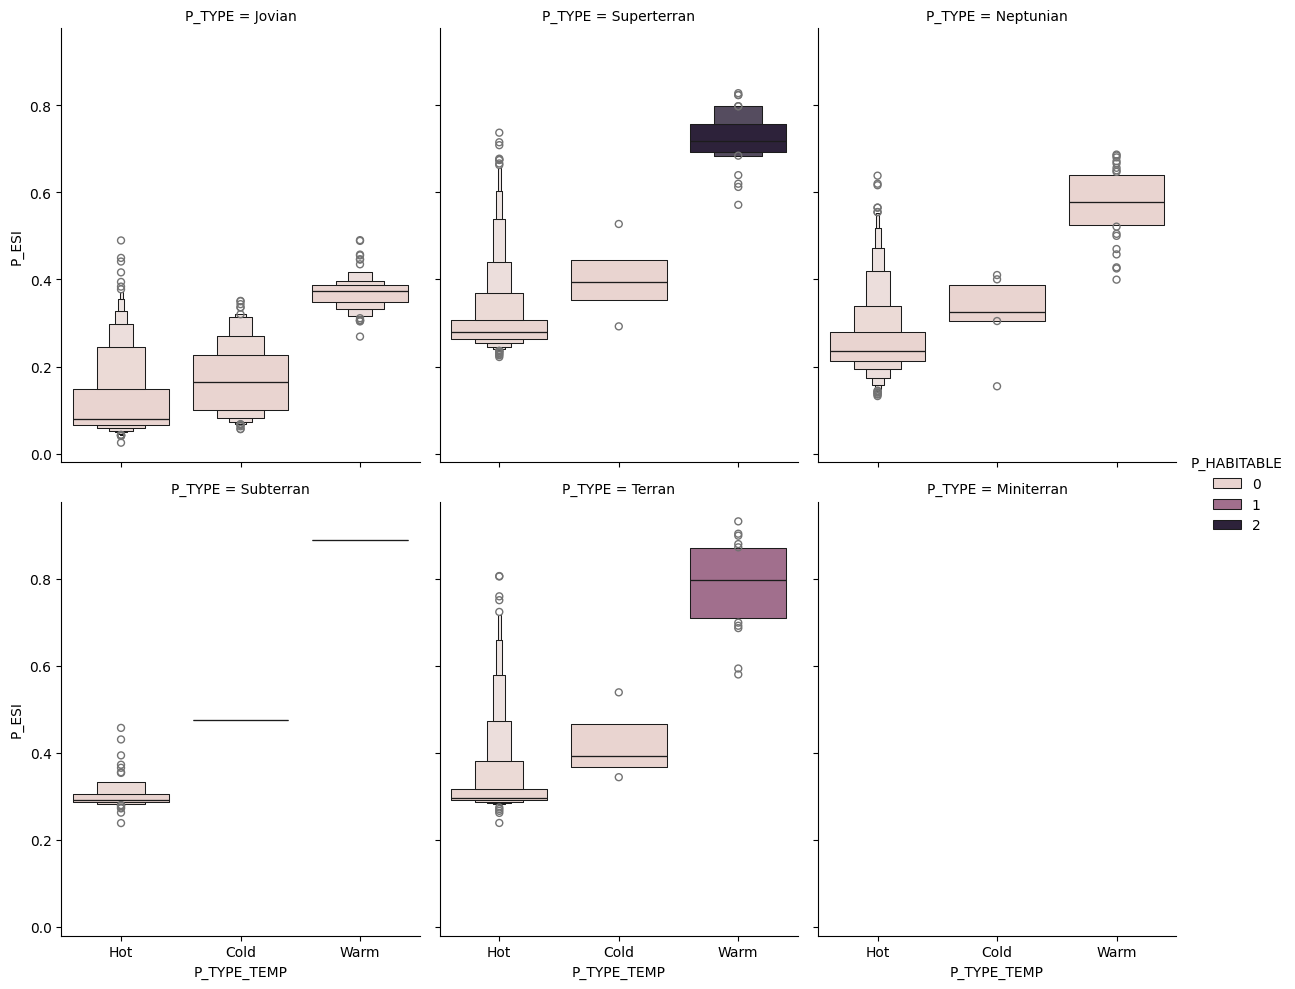

In [12]:
df = df.reset_index(drop=True)
sns.catplot(x='P_TYPE_TEMP', y='P_ESI', hue= 'P_HABITABLE', col='P_TYPE', col_wrap=3, aspect=0.8, kind='boxen', data=df)
plt.savefig("P_type-by-temp.png")

We infer that a higher P_ESI is associated with a greater potential for habitability, as planets with higher ESI values have physical characteristics that are more similar to those of Earth. 

For super-Earth planets, the warm thermal type is associated with a higher number of optimistically habitable planets. In contrast, for terrestrial planets, the warm thermal type is associated with a higher number of conservatively habitable planets. These observations suggest that both planetary type and thermal characteristics may influence the potential habitability of exoplanets.

**Star constellation having habitable planets**

Let's plot names of the star constellations where most of the habitable exoplanets belong.

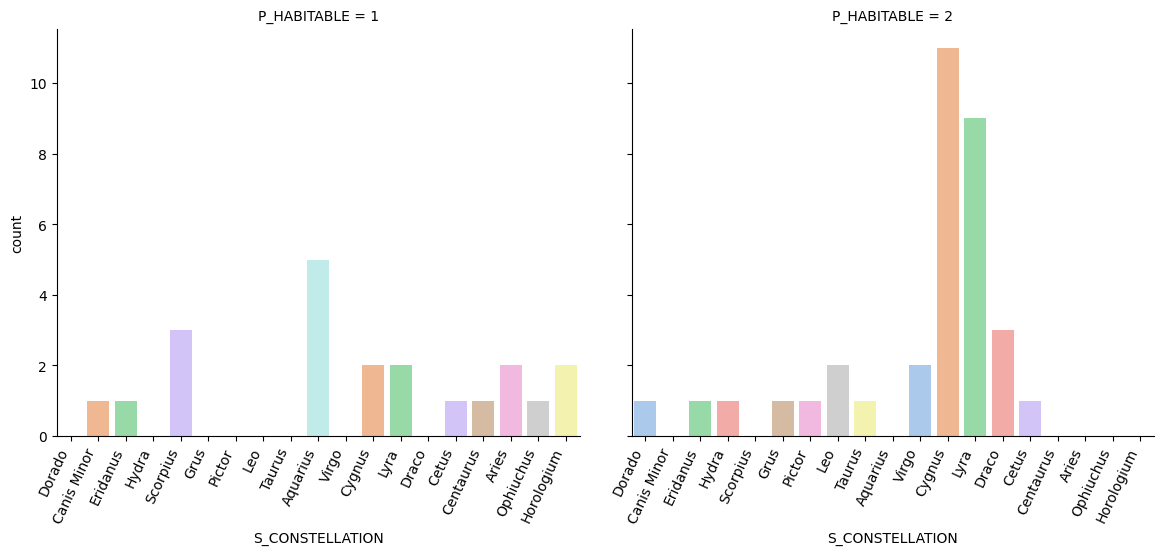

In [13]:
label_size = 10
plt.rcParams['xtick.labelsize'] = label_size
chart = sns.catplot(data=df[df['P_HABITABLE'].isin([1,2])],
                    x= 'S_CONSTELLATION',
                    kind = 'count',
                    palette = 'pastel',
                    col='P_HABITABLE',
                    aspect=1.2,)

chart.set_xticklabels(rotation=65, horizontalalignment='right')
plt.savefig("p-type-by-constellations.png")

We can note that constellation Aquarius has maximum number of potentially habitable exoplanets. Cygnus and Lyra has maximum number of Positive Habitual exoplanets.

**Time Frame when planets with high ESI**

Now we will see how many exoplanets discoverd have high ESI

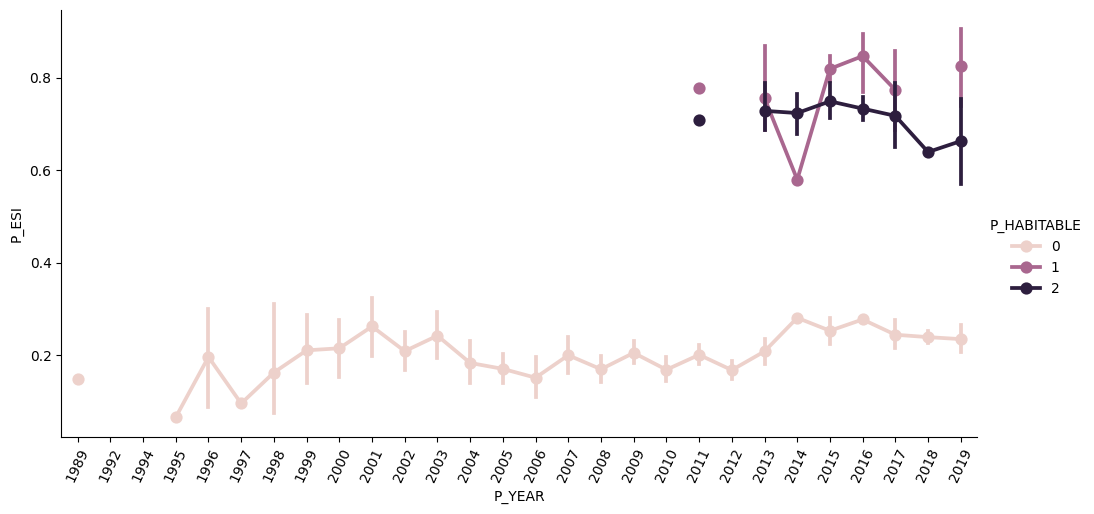

In [14]:
p_plot = sns.catplot(x='P_YEAR', y= 'P_ESI', hue='P_HABITABLE', kind= 'point', data=df, aspect=2.0)
p_plot.set_xticklabels(rotation=65)

Till 2013, only inhabitable planets had ESI <= 0.3 were discovered. From 2011-2019, habitable planets with ESI in the range of 0.6-0.9 have been discovered. 

**Influence of Planet mass/ Planet radius/ Planet eccentricity on habitability.**

In [15]:
import plotly.express as px
fig = px.scatter(df, x= df.P_MASS, y = df.P_ESI, color=df.P_HABITABLE, hover_name=df.P_NAME, log_x=True, size_max=30)
fig.show()

Planet mass in range 0.4 to 3.93 units corresponds to potentialy habitual exoplanets. Planet mass in range 5.4 to 8.92 units corresponds to positively habitual exoplanets. It is also important to note that, potentially habitual exoplanets have more ESI range then positively habitual exoplanets.  

In [19]:
import plotly.express as px
fig = px.scatter(df, x= df.P_RADIUS, y = df.P_ESI, color=df.P_HABITABLE, hover_name=df.P_NAME, log_x=True, size_max=30)

fig.show()

Planet radius in range 0.77 to 1.41 units correspond to conservatively habitable exoplanets. Planet radius in range 1.52 to 2.46 units correspond to optimistically habitable exoplanets. It is interesting to note that in most of the cases, conservatively habitable exoplanets have a bit higher ESI compared to the ESI of optimistically habitable exoplanets.

In [16]:
import plotly.express as px
fig = px.scatter(df, x= df.P_ECCENTRICITY, y = df.P_ESI, color=df.P_HABITABLE, hover_name=df.P_NAME, log_x=True, size_max=30)
fig.show()

Planet's eccentricity in the range 0.02 to 0.35 units indicate a possibility of habitability.

**Influence of Planetary Flux on habitability**

In [17]:
ESI_range = df.query("P_ESI> 0.65") 
fig = px.bar(ESI_range, x= 'P_NAME', y="P_FLUX", color = 'P_HABITABLE')
fig.show()

We can clearly see that, very high flux is associated with  in habitual planets and moderately high flux is associated with positive habitual planets.Potentially habitable planets have comparatively low flux.

**Influence of age of planet(P_PERIOD) on habitability**

In [18]:
fig = px.line(ESI_range, x="P_NAME", y= "P_PERIOD", color = 'P_HABITABLE',line_group="P_TYPE")
fig.show()

We can see that potentially habitual cluster of exoplanets have period ranging between 9 days to 267 days. 

Positively habitual cluster of exoplanets have a period ranging 3 days to 220 days.

### **PREPRCESSING**

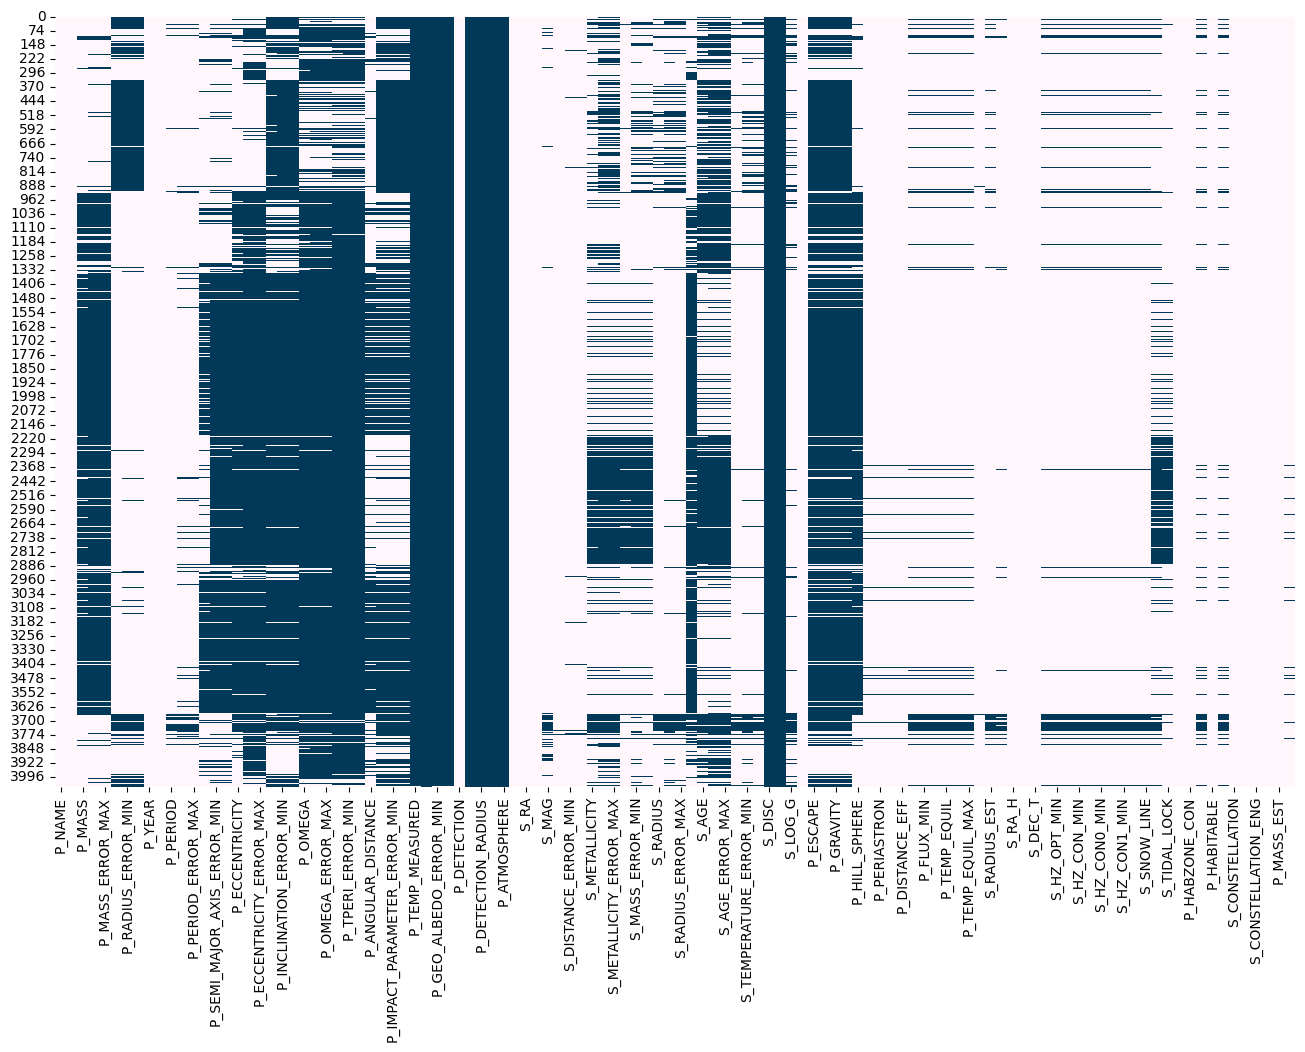

In [19]:
#Plots a heatmap of the missing values in the dataset
plt.figure(figsize=(16, 10))

sns.heatmap(df.isnull(), cbar=False, cmap='PuBu') 
plt.savefig('Null-values-distribution.png')
plt.show()

In [20]:
null_values = df.isnull().sum().sort_values(ascending = False)
percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)

missing = pd.concat([null_values,percent], axis = 1, keys=['Total', "Percent"])
missing.head(40)

,Total,Percent
P_ATMOSPHERE,4048,1.000000
P_ALT_NAMES,4048,1.000000
P_DETECTION_RADIUS,4048,1.000000
P_GEO_ALBEDO,4048,1.000000
P_DETECTION_MASS,4048,1.000000
S_MAGNETIC_FIELD,4048,1.000000
S_DISC,4048,1.000000
P_TEMP_MEASURED,4043,0.998765
P_GEO_ALBEDO_ERROR_MIN,4043,0.998765
P_GEO_ALBEDO_ERROR_MAX,4043,0.998765


We can safely remove those features which have missing values > 50% of data to reduce bias.

In [21]:
#Dropping all the columns with null  values
df = df.drop( [ 'P_DETECTION_MASS', 'P_GEO_ALBEDO','S_MAGNETIC_FIELD', 'S_DISC', 'P_ATMOSPHERE', 'P_ALT_NAMES', 'P_DETECTION_RADIUS', 'P_GEO_ALBEDO_ERROR_MIN', 'P_TEMP_MEASURED','P_GEO_ALBEDO_ERROR_MAX', 'P_TPERI_ERROR_MAX', 'P_TPERI_ERROR_MIN', 'P_TPERI', 'P_OMEGA_ERROR_MIN', 'P_OMEGA_ERROR_MAX', 'P_DENSITY', 'P_ESCAPE', 'P_POTENTIAL', 'P_GRAVITY', 'P_OMEGA', 'P_INCLINATION_ERROR_MAX', 'P_INCLINATION_ERROR_MIN', 'P_INCLINATION','P_ECCENTRICITY_ERROR_MAX', 'P_ECCENTRICITY_ERROR_MIN', 'S_TYPE','P_ECCENTRICITY','P_IMPACT_PARAMETER_ERROR_MIN','P_IMPACT_PARAMETER_ERROR_MAX', 'P_IMPACT_PARAMETER', 'P_MASS_ERROR_MAX','P_MASS_ERROR_MIN', 'P_HILL_SPHERE', 'P_SEMI_MAJOR_AXIS_ERROR_MIN','P_SEMI_MAJOR_AXIS_ERROR_MAX', 'P_MASS', 'S_AGE_ERROR_MAX','S_AGE_ERROR_MIN', 'S_AGE', 'P_ANGULAR_DISTANCE', 'P_SEMI_MAJOR_AXIS'], axis=1)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4048 entries, 0 to 4047
Data columns (total 71 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   P_NAME                   4048 non-null   object 
 1   P_STATUS                 4048 non-null   float64
 2   P_RADIUS                 3139 non-null   float64
 3   P_RADIUS_ERROR_MIN       3105 non-null   float64
 4   P_RADIUS_ERROR_MAX       3105 non-null   float64
 5   P_YEAR                   4048 non-null   int64  
 6   P_UPDATED                4048 non-null   object 
 7   P_PERIOD                 3938 non-null   float64
 8   P_PERIOD_ERROR_MIN       3807 non-null   float64
 9   P_PERIOD_ERROR_MAX       3807 non-null   float64
 10  P_DETECTION              4048 non-null   object 
 11  S_NAME                   4048 non-null   object 
 12  S_RA                     4048 non-null   float64
 13  S_DEC                    4048 non-null   float64
 14  S_MAG                   

Working with categorical columns

In [23]:
df.select_dtypes(include=['object']).columns

Index(['P_NAME', 'P_UPDATED', 'P_DETECTION', 'S_NAME', 'S_ALT_NAMES', 'P_TYPE',
       'S_TYPE_TEMP', 'S_RA_T', 'S_DEC_T', 'P_TYPE_TEMP', 'S_CONSTELLATION',
       'S_CONSTELLATION_ABR', 'S_CONSTELLATION_ENG'],
      dtype='object')

In [24]:
cat_column = df.select_dtypes(include=['object'])
null_values = cat_column.isnull().sum().sort_values(ascending = False)
percent = (null_values/cat_column.isnull().count()).sort_values(ascending=False)

missing = pd.concat([null_values,percent], axis = 1, keys=['Total', "Percent"])
missing.head(40)


,Total,Percent
P_TYPE_TEMP,327,0.080781
S_TYPE_TEMP,136,0.033597
P_TYPE,17,0.004200
P_UPDATED,0,0.000000
P_NAME,0,0.000000
S_ALT_NAMES,0,0.000000
S_NAME,0,0.000000
P_DETECTION,0,0.000000
S_RA_T,0,0.000000
S_DEC_T,0,0.000000


Imputing the columns with high null values.

In [25]:
df['P_TYPE_TEMP'] = df['P_TYPE_TEMP'].fillna(df['P_TYPE_TEMP'].mode()[0])
df['S_TYPE_TEMP'] = df['S_TYPE_TEMP'].fillna(df['S_TYPE_TEMP'].mode()[0])
df['P_TYPE'] = df['P_TYPE'].fillna(df['P_TYPE'].mode()[0])

In [26]:
encoders = {}

for col in cat_column:
    encoders[col] = LabelEncoder()

    df[col] = encoders[col].fit_transform(df[col])

In [27]:
imputed_data = df.copy(deep=True)

mice_imputer = IterativeImputer()

imputed_data.iloc[:,:] = mice_imputer.fit_transform(df)

imputed_data.head()

,P_NAME,P_STATUS,P_RADIUS,P_RADIUS_ERROR_MIN,P_RADIUS_ERROR_MAX,P_YEAR,P_UPDATED,P_PERIOD,P_PERIOD_ERROR_MIN,P_PERIOD_ERROR_MAX,...,P_HABZONE_CON,P_TYPE_TEMP,P_HABITABLE,P_ESI,S_CONSTELLATION,S_CONSTELLATION_ABR,S_CONSTELLATION_ENG,P_RADIUS_EST,P_MASS_EST,P_SEMI_MAJOR_AXIS_EST
0,0,3.0,4.798394,8.016521,-1.805102,2007,0,326.03000,-0.32,0.32,...,0,1,0,0.083813,24,24,5,12.082709,6165.86330,1.29
1,1,3.0,4.798394,8.016521,-1.805102,2009,146,516.21997,-3.20,3.20,...,0,1,0,0.082414,83,83,42,12.229641,4684.78480,1.53
2,2,3.0,4.798394,8.016521,-1.805102,2008,0,185.84000,-0.23,0.23,...,0,1,0,0.081917,0,0,2,12.848516,1525.57440,0.83
3,3,3.0,4.798394,8.016521,-1.805102,2002,146,1773.40000,-2.50,2.50,...,0,0,0,0.145241,39,39,34,12.865261,1481.07850,2.93
4,4,3.0,4.798394,8.016521,-1.805102,1996,146,798.50000,-1.00,1.00,...,1,2,0,0.368627,30,30,75,13.421749,565.73385,1.66


In [28]:
imputed_data.isna().sum(axis=0)

P_NAME                   0
P_STATUS                 0
P_RADIUS                 0
P_RADIUS_ERROR_MIN       0
P_RADIUS_ERROR_MAX       0
                        ..
S_CONSTELLATION_ABR      0
S_CONSTELLATION_ENG      0
P_RADIUS_EST             0
P_MASS_EST               0
P_SEMI_MAJOR_AXIS_EST    0
Length: 71, dtype: int64

In [29]:
from collections import Counter
counter_ = Counter(imputed_data['P_HABITABLE'])
for class_label_, example_num_ in counter_.items():
    percentage_ = example_num_ / len(imputed_data['P_HABITABLE']) * 100
    print('Class=%d, n=%d (%.3f%%)' % (class_label_, example_num_, percentage_))

Class=0, n=3993 (98.641%)
Class=2, n=34 (0.840%)
Class=1, n=21 (0.519%)


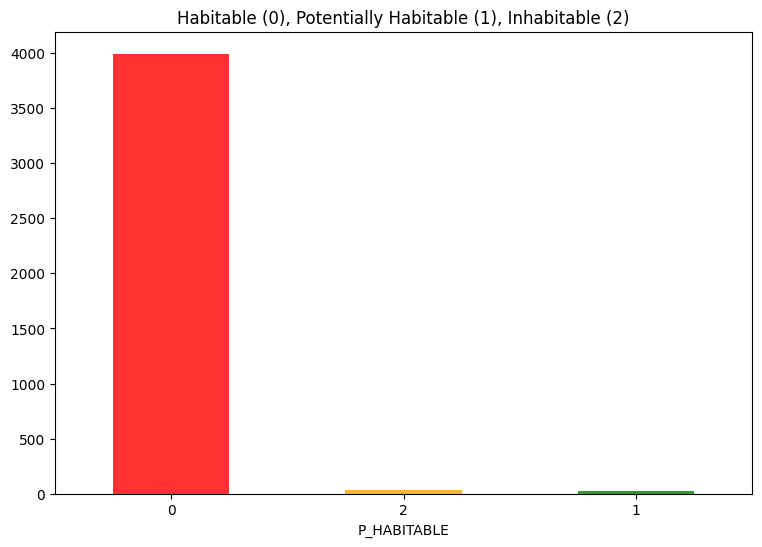

In [30]:
fig = plt.figure(figsize = (9,6))

imputed_data.P_HABITABLE.value_counts(ascending=False).plot(kind = 'bar', color= ['red', 'orange', 'green'], alpha = 0.8, rot = 0)

plt.title('Habitable (0), Potentially Habitable (1), Inhabitable (2)')
plt.savefig("Class-Imbalance.png")
plt.show()

Balancing the imbalanced data

In [31]:
from imblearn.combine import SMOTEENN

X= imputed_data.drop(columns=["P_HABITABLE"],axis=1)
y = imputed_data["P_HABITABLE"]

smt = SMOTEENN(random_state = 0)
X,y = smt.fit_resample(X,y)

counter = Counter(y)
for class_label, example_num in counter.items():
    percentage = example_num / len(y) * 100
    print('Class=%d, n=%d (%.3f%%)' % (class_label, example_num, percentage))

Class=0, n=3843 (32.925%)
Class=1, n=3993 (34.210%)
Class=2, n=3836 (32.865%)


In [32]:
sample_data = X
sample_data["P_HABITABLE"] = y

In [33]:
sample_data.shape

(11672, 71)

<Axes: >

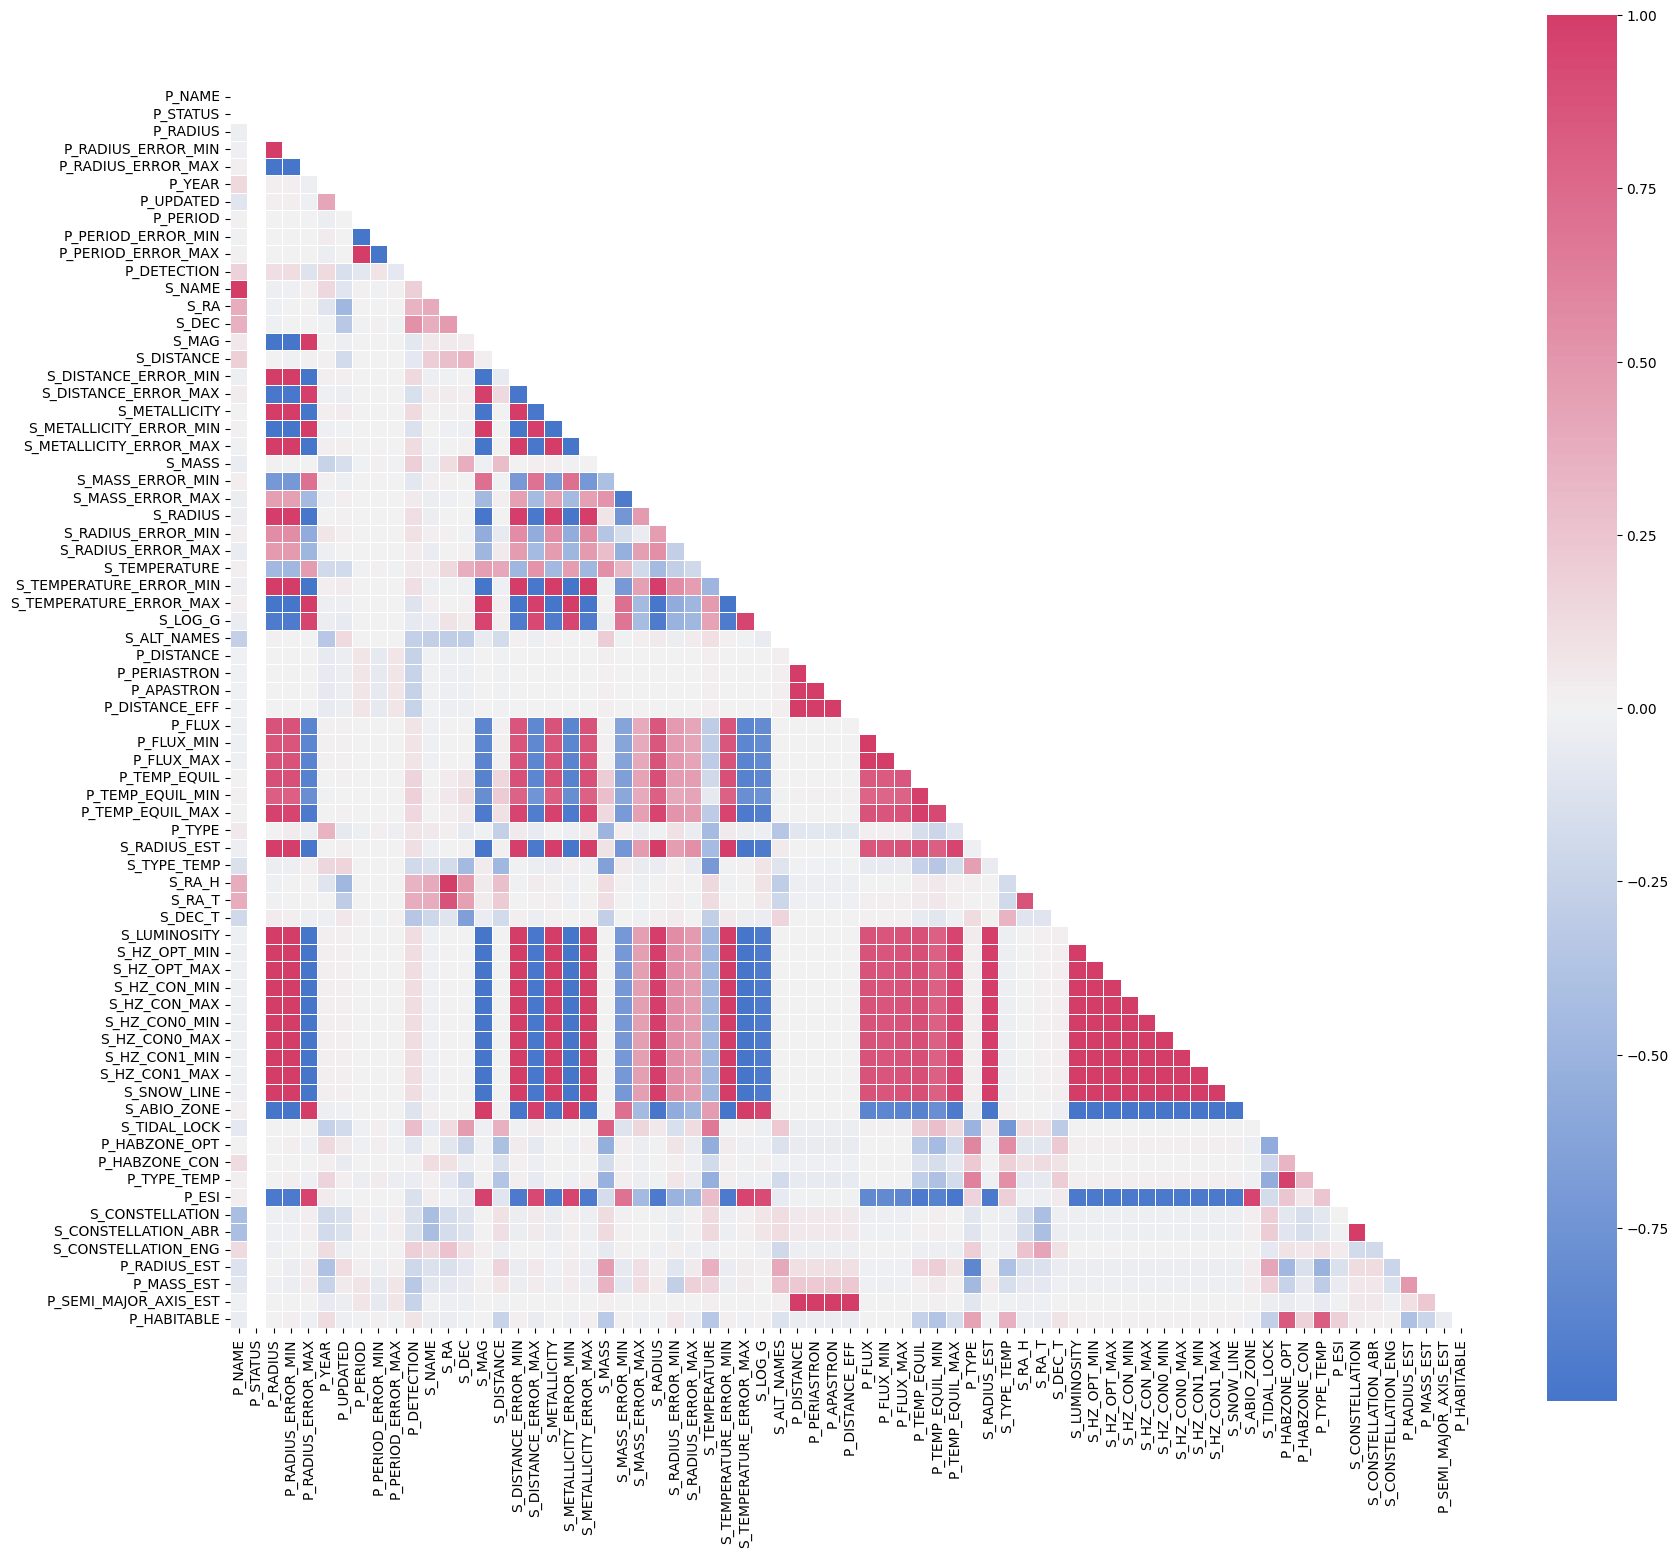

In [34]:
correlation = sample_data.corr()
mask = np.triu(np.ones_like(correlation, dtype=np.bool))
f,ax = plt.subplots(figsize=(20,20))
cmap = sns.diverging_palette(255, 0, as_cmap = True)

sns.heatmap(correlation, mask=mask, cmap=cmap, center=0, square=True,annot=False, linewidths=.5, cbar_kws={"shrink": 0.9})

In [35]:
upper_triangle = correlation.where(np.triu(np.ones(correlation.shape),k=1).astype(np.bool_))

to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column]>0.95)]

print(to_drop)

['P_RADIUS_ERROR_MIN', 'P_PERIOD_ERROR_MAX', 'S_NAME', 'S_MAG', 'S_DISTANCE_ERROR_MIN', 'S_DISTANCE_ERROR_MAX', 'S_METALLICITY', 'S_METALLICITY_ERROR_MIN', 'S_METALLICITY_ERROR_MAX', 'S_RADIUS', 'S_TEMPERATURE_ERROR_MIN', 'S_TEMPERATURE_ERROR_MAX', 'S_LOG_G', 'P_PERIASTRON', 'P_APASTRON', 'P_DISTANCE_EFF', 'P_FLUX_MIN', 'P_FLUX_MAX', 'P_TEMP_EQUIL_MIN', 'P_TEMP_EQUIL_MAX', 'S_RADIUS_EST', 'S_RA_H', 'S_LUMINOSITY', 'S_HZ_OPT_MIN', 'S_HZ_OPT_MAX', 'S_HZ_CON_MIN', 'S_HZ_CON_MAX', 'S_HZ_CON0_MIN', 'S_HZ_CON0_MAX', 'S_HZ_CON1_MIN', 'S_HZ_CON1_MAX', 'S_SNOW_LINE', 'S_ABIO_ZONE', 'P_TYPE_TEMP', 'P_ESI', 'S_CONSTELLATION_ABR', 'P_SEMI_MAJOR_AXIS_EST']


Dropping the highly co-related columns

In [36]:
preprocessed_data = sample_data.drop(['P_RADIUS_ERROR_MIN', 'P_RADIUS_ERROR_MAX',
'P_PERIOD_ERROR_MIN', 'P_PERIOD_ERROR_MAX', 'S_NAME', 'S_MAG','S_DISTANCE_ERROR_MIN','S_DISTANCE_ERROR_MAX', 'S_METALLICITY', 'S_METALLICITY_ERROR_MIN','S_METALLICITY_ERROR_MAX', 'S_RADIUS', 'S_TEMPERATURE_ERROR_MIN','S_TEMPERATURE_ERROR_MAX', 'S_LOG_G', 'P_PERIASTRON', 'P_APASTRON', 'P_DISTANCE_EFF','P_FLUX_MIN', 'P_FLUX_MAX', 'P_TEMP_EQUIL_MIN', 'P_TEMP_EQUIL_MAX', 'S_RADIUS_EST','S_RA_H', 'S_LUMINOSITY', 'S_HZ_OPT_MIN', 'S_HZ_OPT_MAX', 'S_HZ_CON_MIN', 'S_HZ_CON_MAX','S_HZ_CON0_MIN', 'S_HZ_CON0_MAX', 'S_HZ_CON1_MIN', 'S_HZ_CON1_MAX', 'S_SNOW_LINE','S_ABIO_ZONE', 'P_TYPE_TEMP', 'P_ESI', 'S_CONSTELLATION_ABR', 'P_SEMI_MAJOR_AXIS_EST'],axis = 1)
preprocessed_data.head()

,P_NAME,P_STATUS,P_RADIUS,P_YEAR,P_UPDATED,P_PERIOD,P_DETECTION,S_RA,S_DEC,S_DISTANCE,...,S_RA_T,S_DEC_T,S_TIDAL_LOCK,P_HABZONE_OPT,P_HABZONE_CON,S_CONSTELLATION,S_CONSTELLATION_ENG,P_RADIUS_EST,P_MASS_EST,P_HABITABLE
0,0,3.0,4.798394,2007,0,326.03000,7,185.17928,17.792868,93.37,...,687,259,0.642400,0,0,24,5,12.082709,6165.86330,0
1,1,3.0,4.798394,2009,146,516.21997,7,229.27454,71.823898,125.72,...,847,2236,0.648683,0,0,83,42,12.229641,4684.78480,0
2,2,3.0,4.798394,2008,0,185.84000,7,352.82257,39.236198,75.59,...,2982,611,0.600010,0,0,0,2,12.848516,1525.57440,0
3,3,3.0,4.798394,2002,146,1773.40000,7,242.60130,43.817646,17.94,...,890,1203,0.445415,0,0,39,34,12.865261,1481.07850,0
4,4,3.0,4.798394,1996,146,798.50000,7,295.46655,50.517525,21.15,...,2448,2114,0.473325,1,1,30,75,13.421749,565.73385,0


**Feature Importance**

In [37]:
features_mat = preprocessed_data.drop(['P_HABITABLE'],axis = 1)
target = preprocessed_data['P_HABITABLE']

In [38]:
#Random Forest Classifier feature importance
selector = SelectFromModel(RandomForestClassifier(n_estimators=1000, random_state=0))
selector.fit(features_mat,target)

support = selector.get_support()

features = features_mat.loc[:,support].columns.tolist()
print(features)
print(RandomForestClassifier(n_estimators = 1000, random_state = 0).fit(features_mat, target).feature_importances_)

['S_MASS', 'S_TEMPERATURE', 'P_FLUX', 'P_TEMP_EQUIL', 'P_TYPE', 'S_TIDAL_LOCK', 'P_HABZONE_OPT', 'P_RADIUS_EST', 'P_MASS_EST']
[0.01011954 0.         0.01341369 0.00214614 0.00096326 0.03099569
 0.00421972 0.00242623 0.00480886 0.02942088 0.0466507  0.00636254
 0.01085003 0.00581407 0.00401169 0.04932591 0.00151618 0.0274125
 0.12337267 0.11660035 0.14456932 0.01018317 0.00212827 0.00214191
 0.03321273 0.13773935 0.00039486 0.00475791 0.0009992  0.08453919
 0.08890345]


In [39]:
selector = SelectFromModel(Ada(random_state=0, n_estimators=50))

selector.fit(features_mat, target)

features = features_mat.loc[:,support].columns.tolist()
print(features)
print(Ada(n_estimators = 1000, random_state = 0).fit(features_mat, target).feature_importances_)

['S_MASS', 'S_TEMPERATURE', 'P_FLUX', 'P_TEMP_EQUIL', 'P_TYPE', 'S_TIDAL_LOCK', 'P_HABZONE_OPT', 'P_RADIUS_EST', 'P_MASS_EST']
[6.10558115e-02 0.00000000e+00 4.77616878e-03 3.87248642e-04
 7.81411883e-04 4.44971606e-02 0.00000000e+00 1.04398854e-03
 1.68457487e-03 4.11098341e-03 5.00799625e-03 6.49192243e-04
 0.00000000e+00 7.18455773e-04 8.96970472e-04 3.36330343e-03
 2.68028755e-04 3.83486244e-02 1.01170805e-01 1.17049814e-01
 4.72132384e-01 1.23952907e-04 6.71055216e-04 1.08312658e-06
 3.80414550e-04 1.25280187e-01 0.00000000e+00 8.60480298e-04
 1.01868041e-03 4.83164496e-03 8.88957905e-03]


In [40]:
del features
del selector 
del features_mat
del target
del X
del y

**Train test split**

In [41]:
final_features = preprocessed_data[['P_PERIOD', 'P_FLUX', 'P_TEMP_EQUIL','P_TYPE', 'P_HABZONE_OPT','P_RADIUS_EST', 'P_MASS_EST', 'S_TYPE_TEMP']]

target = preprocessed_data['P_HABITABLE']

X_train, X_test, y_train, y_test = train_test_split(final_features, target, test_size=0.33, random_state=42)
print(f"X_train dimentions: {X_train.shape}")
print(f"X_test dimentions: {X_test.shape}")
print(f"y_train dimentions: {y_train.shape}")
print(f"y_test dimentions: {y_test.shape}")

X_train dimentions: (7820, 8)
X_test dimentions: (3852, 8)
y_train dimentions: (7820,)
y_test dimentions: (3852,)


**Scaling the features**

In [42]:
scaler = MinMaxScaler()
X_train= scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

# **TRAINING**

Training all the different models

In [43]:
def plot_confusion_mat(y_test,y_pred):
    conf_mat = confusion_matrix(y_test, y_pred)

    confusion_matrix_df = pd.DataFrame(conf_mat, index = ['Inhabitable',
    'Potentially Habitable', 'Positively Habitable'], columns = ['Inhabitable', 'Potentially Habitable', 'Positively Habitable'])

    plt.figure(figsize = (5,4))
    sns.heatmap(confusion_matrix_df, annot = True)
    plt.title('Habitability Confusion Matrix')
    plt.ylabel('Actal Values')
    plt.xlabel('Predicted Values')
    plt.show()

    return conf_mat

In [44]:
#Decision Tree


dt = DecisionTreeClassifier()


param_grid = {'max_depth': np.arange(2, 10, 1), 
            'max_leaf_nodes': np.arange(2, 100, 10),
            'random_state': [0, 1, 2, 3, 4, 5],
            'splitter': ['best', 'random']}



grid_search = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid=param_grid,
    refit=True, 
    verbose=0
)
grid_search.fit(X_train, y_train)


best_dt = grid_search.best_estimator_

print(f"Best Parameters: {grid_search.best_params_}")


Best Parameters: {'max_depth': np.int64(4), 'max_leaf_nodes': np.int64(12), 'random_state': 0, 'splitter': 'best'}


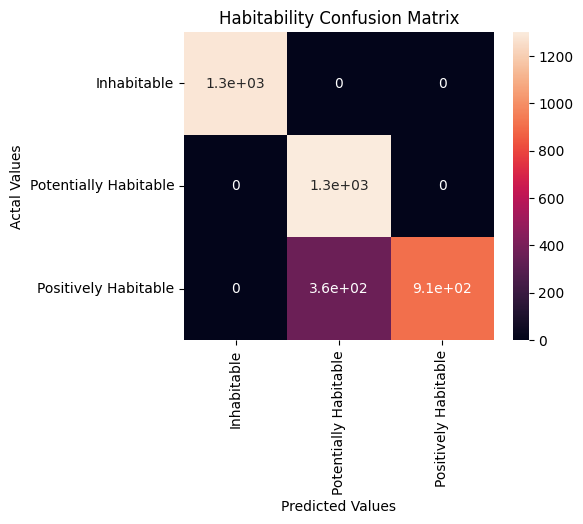

Decision Tree classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1284
           1       0.78      1.00      0.88      1301
           2       1.00      0.72      0.83      1267

    accuracy                           0.91      3852
   macro avg       0.93      0.91      0.90      3852
weighted avg       0.93      0.91      0.90      3852

Accuracy:  0.9068
Precision: 0.9279
F1 Macro:  0.9046
Recall:    0.9056


In [45]:
t0 = time.time()

dt_model = DecisionTreeClassifier(splitter='random', max_depth=6, random_state=0, max_leaf_nodes=12).fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

dt_time = time.time()-t0

confusion_mat =  plot_confusion_mat(y_test, dt_predictions)

print(f"Decision Tree classification Report:\n")
print(classification_report(y_test, dt_predictions))

dt_accuracy = accuracy_score(y_test, dt_predictions)
precision = precision_score(y_test, dt_predictions, average='macro')
f1 = f1_score(y_test, dt_predictions, average='macro')
recall = recall_score(y_test, dt_predictions, average='macro')

print(f"Accuracy:  {dt_accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Macro:  {f1:.4f}")
print(f"Recall:    {recall:.4f}")

del confusion_mat

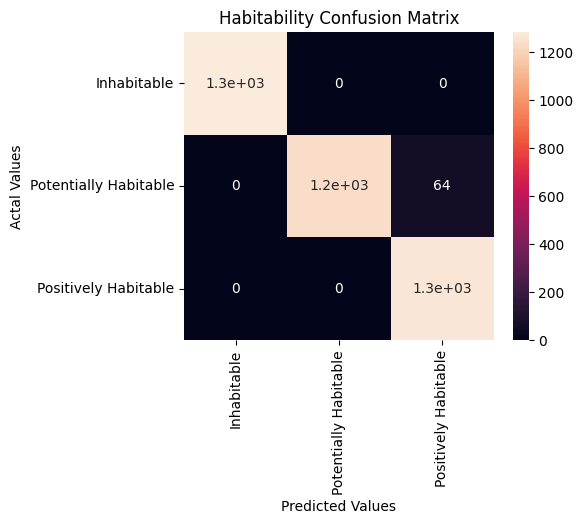

KNN classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1284
           1       1.00      0.95      0.97      1301
           2       0.95      1.00      0.98      1267

    accuracy                           0.98      3852
   macro avg       0.98      0.98      0.98      3852
weighted avg       0.98      0.98      0.98      3852

Accuracy:  0.9834
Precision: 0.9840
F1 Macro:  0.9834
Recall:    0.9836


In [46]:
t0 = time.time()
knn_model = KNeighborsClassifier(n_neighbors = 3).fit(X_train, y_train)

knn_predictions = knn_model.predict(X_test)
knn_time = time.time()-t0

confusion_mat = plot_confusion_mat(y_test, knn_predictions)

knn_accuracy = accuracy_score(y_test, knn_predictions)
precision = precision_score(y_test, knn_predictions, average='macro')
f1 = f1_score(y_test, knn_predictions, average='macro')
recall = recall_score(y_test, knn_predictions, average='macro')

print(f"KNN classification Report:\n")
print(classification_report(y_test, knn_predictions))


print(f"Accuracy:  {knn_accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Macro:  {f1:.4f}")
print(f"Recall:    {recall:.4f}")

del confusion_mat 

In [47]:
#Gradient Boosting

gb = GradientBoostingClassifier()

param_grid = {
'criterion': ['friedman_mse',  'mse'],
            'n_estimators': np.arange(10, 100, 10)}

grid_search = GridSearchCV(gb, param_grid, refit = True, verbose=1)

grid_search.fit(X_train, y_train)

best_gb = grid_search.best_estimator_

print(f"Best Parameters: {best_gb}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Parameters: GradientBoostingClassifier(n_estimators=np.int64(50))


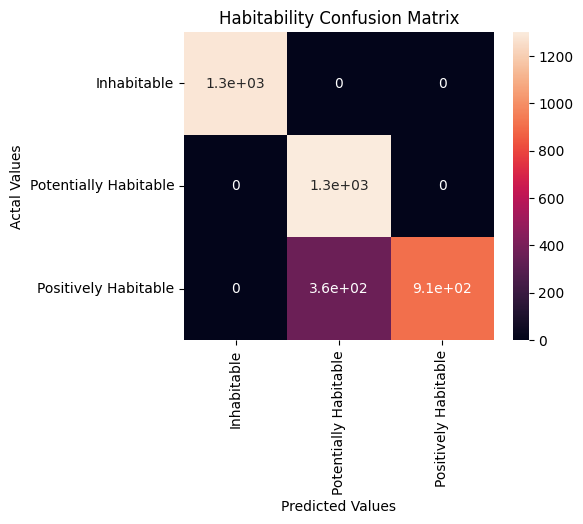

Gradient Boosting classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1284
           1       0.78      1.00      0.88      1301
           2       1.00      0.72      0.83      1267

    accuracy                           0.91      3852
   macro avg       0.93      0.91      0.90      3852
weighted avg       0.93      0.91      0.90      3852

Accuracy:  0.9068
Precision: 0.9279
F1 Macro:  0.9046
Recall:    0.9056


In [48]:
t0 = time.time()

gb_model = GradientBoostingClassifier(loss = 'log_loss', n_estimators = 10,criterion = 'friedman_mse', max_depth = 6,random_state = 0,max_leaf_nodes = 12).fit(X_train, y_train)

gb_predictions = dt_model.predict(X_test)

gb_time = time.time()-t0

confusion_mat =  plot_confusion_mat(y_test, gb_predictions)

print(f"Gradient Boosting classification Report:\n")
print(classification_report(y_test, gb_predictions))

gb_accuracy = accuracy_score(y_test, gb_predictions)
precision = precision_score(y_test, gb_predictions, average='macro')
f1 = f1_score(y_test, gb_predictions, average='macro')
recall = recall_score(y_test, gb_predictions, average='macro')

print(f"Accuracy:  {gb_accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Macro:  {f1:.4f}")
print(f"Recall:    {recall:.4f}")

del confusion_mat

# **MODEL COMPARISON**

In [49]:
def plot_model_log(log):
    fig, ax1 = plt.subplots(figsize = (10, 5))
    ax1.set_title('Accuracy and Time taken', fontsize = 13)
    color = 'tab:green'
    ax1.set_xlabel('Classifier', fontsize = 13)
    ax1.set_ylabel('Time taken', fontsize = 13, color = color)
    ax2 = sns.barplot(x = 'Classifier', y = 'Time taken', data = log, palette = 'summer')
    ax1.tick_params(axis = 'y')
    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('Accuracy', fontsize = 13, color = color)
    ax2 = sns.lineplot(x = 'Classifier', y = 'Accuracy', data = log, sort = False, color = color)
    ax2.tick_params(axis = 'y', color = color)

          Classifier  Accuracy  Time taken
0      Decision Tree  0.906802    0.002356
1                KNN  0.983385    0.092531
2  Gradient Boosting  0.906802    0.323953


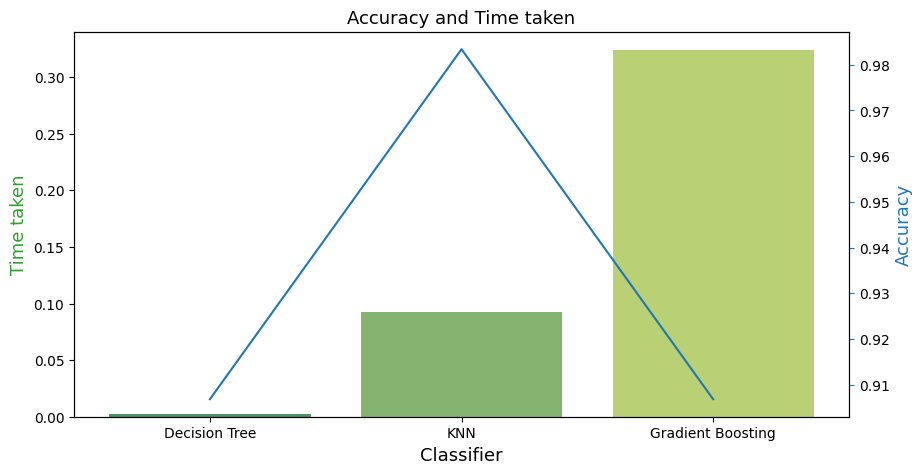

In [50]:
accuracy_list = [dt_accuracy, knn_accuracy, gb_accuracy]
time_list = [dt_time, knn_time, gb_time]
log_data = {'Classifier': ['Decision Tree','KNN','Gradient Boosting'],
            'Accuracy': accuracy_list,
            'Time taken': time_list}

clf_log= pd.DataFrame(log_data)

plot_model_log(clf_log)
print(clf_log)

In [55]:
# Final Verdict

print("\n" + "="*60)
print("                    FINAL VERDICT")
print("="*60)

print("\nModel Performance:")
print("-" * 60)

models = {
    "Gradient Boosting": {
        "Accuracy": 0.9068,
        "Precision": 0.9279,
        "Recall": 0.9056,
        "F1 Macro": 0.9046,
        "Time": 0.323745
    },
    "Decision Tree": {
        "Accuracy": 0.9068,
        "Precision": 0.9279,
        "Recall": 0.9056,
        "F1 Macro": 0.9046,
        "Time": 0.002650
    },
    "KNN": {
        "Accuracy": 0.9834,
        "Precision": 0.9840,
        "Recall": 0.9836,
        "F1 Macro": 0.9834,
        "Time": 0.094308
    }
}

for model, metrics in models.items():
    print(f"\n{model}:")
    print(f"  Accuracy  : {metrics['Accuracy']:.4f}")
    print(f"  Precision : {metrics['Precision']:.4f}")
    print(f"  Recall    : {metrics['Recall']:.4f}")
    print(f"  F1 Macro  : {metrics['F1 Macro']:.4f}")
    print(f"  Time      : {metrics['Time']:.6f} seconds")

print("\n" + "-"*60)
print("Final winner")

print("""
KNN is the best-performing classifier for this dataset.

It achieves:
  • Accuracy : 98.34%
  • Precision: 98.40%
  • Recall   : 98.36%
  • F1 Macro : 98.34%

Although the Decision Tree is the fastest model, its accuracy
is only 90.68%. Gradient Boosting also achieves 90.68% accuracy
but takes considerably longer to execute.

Therefore, KNN is recommended because it provides the highest
and most balanced classification performance while maintaining
a reasonable execution time.
""")



                    FINAL VERDICT

Model Performance:
------------------------------------------------------------

Gradient Boosting:
  Accuracy  : 0.9068
  Precision : 0.9279
  Recall    : 0.9056
  F1 Macro  : 0.9046
  Time      : 0.323745 seconds

Decision Tree:
  Accuracy  : 0.9068
  Precision : 0.9279
  Recall    : 0.9056
  F1 Macro  : 0.9046
  Time      : 0.002650 seconds

KNN:
  Accuracy  : 0.9834
  Precision : 0.9840
  Recall    : 0.9836
  F1 Macro  : 0.9834
  Time      : 0.094308 seconds

------------------------------------------------------------
Final winner

KNN is the best-performing classifier for this dataset.

It achieves:
  • Accuracy : 98.34%
  • Precision: 98.40%
  • Recall   : 98.36%
  • F1 Macro : 98.34%

Although the Decision Tree is the fastest model, its accuracy
is only 90.68%. Gradient Boosting also achieves 90.68% accuracy
but takes considerably longer to execute.

Therefore, KNN is recommended because it provides the highest
and most balanced classificatio

In [56]:
from sklearn.pipeline import Pipeline
import joblib

pipeline = Pipeline([
    ("scaler", scaler),
    ("model", knn_model)
])

joblib.dump(pipeline, "model.pkl")

['model.pkl']